# Phase A-2: 构建 Item Latent Factors

## 目标
为 39,001 个 item 构建 7 个 latent factor，与 user_latent 对齐到同一空间。

## 7 个 Item Factor
| # | Factor | 维度 | 来源 |
|---|--------|------|------|
| 1 | content_type | 3 (one-hot) | content_features.content_type |
| 2 | theme_embedding | 50 | item theme → user-side SVD 投影 |
| 3 | quality_score | 1 | like/fav/comment/share_rate 加权 |
| 4 | price_tier | 1 | pricing 归一化 |
| 5 | skill_requirements | 32 | title+description → user-side TF-IDF 投影 |
| 6 | freshness | 1 | updated_at → 相对时间归一化 |
| 7 | popularity | 1 | view_count + like_count 综合 |

## 输出
- `item_latent` 矩阵: 39,001 × 89 (3+50+1+1+32+1+1)
- 保存为 `data/item_latent.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = ['SimHei', 'Microsoft YaHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

DATA_SRC = 'D:/dev/projects/zhere_olap/data/recommendation'
print('Setup OK')

Setup OK


In [2]:
# 加载数据（复用 Phase A-1 逻辑）
users = pd.read_csv(f'{DATA_SRC}/hybrid_user_profile.csv', encoding='utf-8-sig')
content_features = pd.read_csv(f'{DATA_SRC}/content_features.csv', encoding='utf-8-sig')
asset = pd.read_csv(f'{DATA_SRC}/published_asset.csv', encoding='utf-8-sig')
prompt = pd.read_csv(f'{DATA_SRC}/published_prompt.csv', encoding='utf-8-sig')
commerce = pd.read_csv(f'{DATA_SRC}/published_commerce.csv', encoding='utf-8-sig')

# ID 解析（user 侧用）
def parse_id_array(val):
    if pd.isna(val) or str(val).strip() in ('', '[]'):
        return []
    s = str(val).strip()
    if s.startswith('[') and s.endswith(']'):
        s = s[1:-1].strip()
        if s == '':
            return []
    return [x.strip() for x in s.split(',') if x.strip() != '']

for col in ['purchase', 'assets', 'works', 'prompt', 'commerce']:
    users[f'{col}_ids'] = users[col].apply(parse_id_array)

# 构建 item_full
cf_dedup = content_features.sort_values('updated_at').drop_duplicates(subset='target_id', keep='last')
cf_lookup = cf_dedup.set_index('target_id')

COMMON_COLS = ['item_id', 'theme', 'pricing', 'location', 'title', 'description', 'definition', 'duration']

def normalize_asset(df):
    return df.rename(columns={'asset_id': 'item_id'})[COMMON_COLS]

def normalize_prompt(df):
    return df.rename(columns={'prompt_id': 'item_id'})[COMMON_COLS]

def normalize_commerce(df):
    df = df.copy()
    df.rename(columns={
        'commerce_id': 'item_id', 'activity': 'theme', 'organization': 'title',
        'requirements': 'description', 'place': 'location', 'budget': 'pricing',
    }, inplace=True)
    df['definition'] = np.nan
    df['duration'] = np.nan
    return df[COMMON_COLS]

item_meta = pd.concat([
    normalize_asset(asset), normalize_prompt(prompt), normalize_commerce(commerce)
], ignore_index=True).drop_duplicates(subset='item_id')
item_meta.set_index('item_id', inplace=True)

item_full = item_meta.join(cf_lookup, how='left')

# content_type backfill
asset_id_set = set(asset['asset_id'])
prompt_id_set = set(prompt['prompt_id'])
commerce_id_set = set(commerce['commerce_id'])
def backfill_ct(iid):
    if iid in asset_id_set: return 'published_asset'
    elif iid in prompt_id_set: return 'published_prompt'
    elif iid in commerce_id_set: return 'published_commerce'
    return None
mask = item_full['content_type'].isna()
item_full.loc[mask, 'content_type'] = item_full.index[mask].map(backfill_ct)

print(f'Loaded: {len(users):,} users, {len(item_full):,} items')
print(f'Content type distribution:')
print(item_full['content_type'].value_counts())

Loaded: 6,006 users, 39,000 items
Content type distribution:
content_type
published_asset       15000
published_prompt      12000
published_commerce    12000
Name: count, dtype: int64


In [3]:
# 重建 user-side 的 SVD 和 TF-IDF，以便将 item 投影到同一空间

# --- 1. Theme SVD (与 Phase A-1 cell-7 相同) ---
# 收集用户 theme 分布矩阵
print('Building user theme distribution matrix...')

# 收集每用户的 item
def collect_user_items(user_row):
    all_ids = []
    for col in ['purchase_ids', 'assets_ids', 'works_ids', 'prompt_ids', 'commerce_ids']:
        all_ids.extend(user_row[col])
    if not all_ids:
        return None
    unique_ids = list(set(all_ids))
    items = item_full.reindex([i for i in unique_ids if i in item_full.index])
    if len(items) == 0:
        return None
    theme_counts = items['theme'].value_counts()
    return {k: v / len(items) for k, v in theme_counts.items()}

all_themes = sorted(item_full['theme'].dropna().unique())
user_theme_matrix = pd.DataFrame(0.0, index=users['user_id'], columns=all_themes)
for idx, row in users.iterrows():
    data = collect_user_items(row)
    if data:
        for theme, weight in data.items():
            if pd.notna(theme) and theme in user_theme_matrix.columns:
                user_theme_matrix.loc[row['user_id'], theme] = weight
    if (idx + 1) % 2000 == 0:
        print(f'  {idx+1}/{len(users)}')

# SVD
THEME_DIM = 50
print(f'Fitting TruncatedSVD({THEME_DIM}) on user theme matrix...')
theme_svd = TruncatedSVD(n_components=THEME_DIM, random_state=42)
theme_svd.fit(user_theme_matrix.values)
print(f'SVD explained variance: {theme_svd.explained_variance_ratio_.cumsum()[-1]*100:.1f}%')

# --- 2. Skill TF-IDF (与 Phase A-1 cell-13 相同) ---
print('\nFitting TF-IDF on user goodat texts...')

def tokenize_goodat(text):
    return [t.strip() for t in re.split(r'[\n,，、；;]+', text) if t.strip() and len(t.strip()) >= 2]

goodat_texts = users['goodat'].fillna('')
skill_tfidf = TfidfVectorizer(
    max_features=32,
    analyzer='word',
    tokenizer=tokenize_goodat,
    sublinear_tf=True
)
skill_tfidf.fit(goodat_texts)
print(f'TF-IDF vocabulary size: {len(skill_tfidf.vocabulary_)}')
print(f'Top features: {skill_tfidf.get_feature_names_out()[:15].tolist()}')

print('\nDone — SVD and TF-IDF ready for item projection.')

Building user theme distribution matrix...
  2000/6006
  4000/6006
  6000/6006
Fitting TruncatedSVD(50) on user theme matrix...
SVD explained variance: 67.4%

Fitting TF-IDF on user goodat texts...
TF-IDF vocabulary size: 32
Top features: ['ae特效合成', 'mg动画制作', 'pr剪辑', 'vlog拍摄', '分镜设计', '动画制作', '后期调色', '多机位剪辑', '字幕制作', '字幕包装', '延时摄影', '微电影导演', '无人机航拍', '灯光布光', '特效合成']

Done — SVD and TF-IDF ready for item projection.


---
## Factor 1: content_type（3 维）
Item 的内容类型 one-hot 编码

Items with exactly one content_type: 39,000 / 39,000
Items with 0 content_type: 0

Distribution:
published_asset       15000
published_prompt      12000
published_commerce    12000
dtype: int64


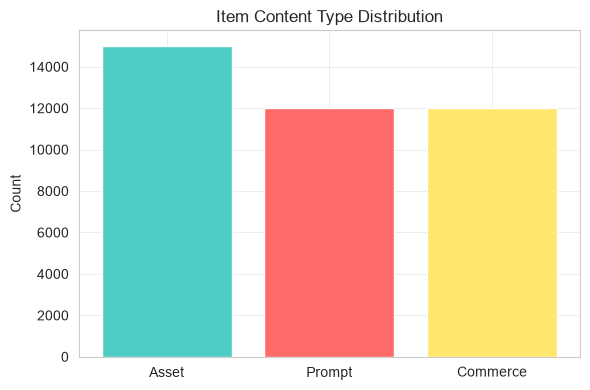

In [4]:
# F1: content_type — one-hot 编码
ct_types = ['published_asset', 'published_prompt', 'published_commerce']
f1 = pd.DataFrame(0, index=item_full.index, columns=ct_types, dtype=int)
for ct in ct_types:
    f1.loc[item_full['content_type'] == ct, ct] = 1

# 验证：每行恰好一个 1
row_sum = f1.sum(axis=1)
print(f'Items with exactly one content_type: {(row_sum == 1).sum():,} / {len(f1):,}')
print(f'Items with 0 content_type: {(row_sum == 0).sum():,}')
print(f'\nDistribution:')
print(f1.sum())

# 可视化
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(ct_types, f1.sum().values, color=['#4ECDC4', '#FF6B6B', '#FFE66D'])
ax.set_xticklabels(['Asset', 'Prompt', 'Commerce'])
ax.set_title('Item Content Type Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

---
## Factor 2: theme_embedding（50 维）
Item theme → one-hot → user-side SVD 投影

Items with missing/unknown theme: 341 / 39,000
F2 theme_embedding: (39000, 50)


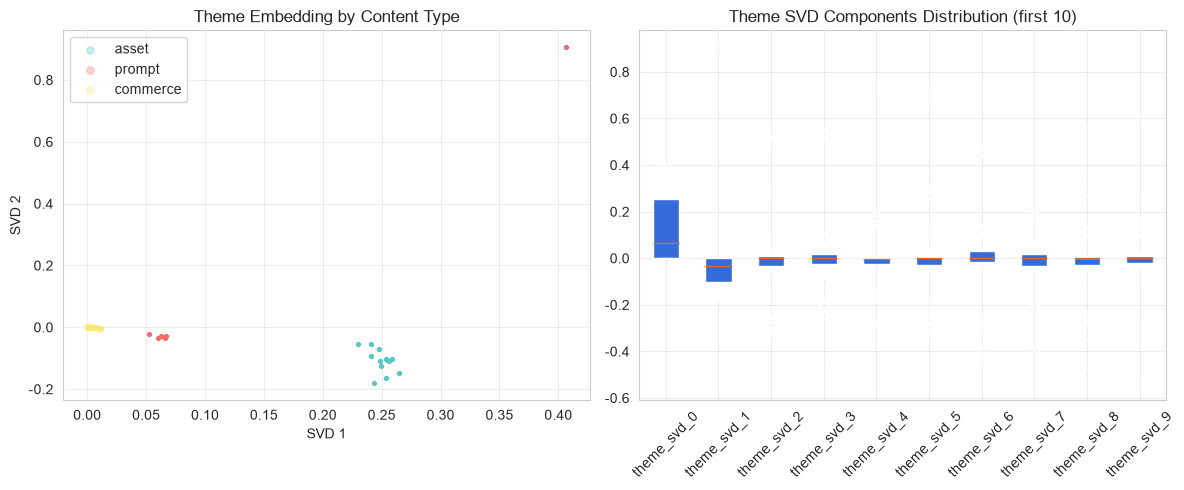

In [5]:
# F2: theme_embedding — item theme one-hot → SVD transform
# SVD.components_ shape: (50, 7470), 每一行是一个 component
# 对于主题 t 的 item: embedding = components_[:, theme_idx] (50,)

theme_to_idx = {t: i for i, t in enumerate(all_themes)}

# 未知 theme 的 item 用零向量
theme_default = np.zeros(THEME_DIM)

f2_data = np.zeros((len(item_full), THEME_DIM))
for i, item_theme in enumerate(item_full['theme']):
    if pd.notna(item_theme) and item_theme in theme_to_idx:
        idx = theme_to_idx[item_theme]
        f2_data[i] = theme_svd.components_[:, idx]  # (50,)
    else:
        f2_data[i] = theme_default

f2 = pd.DataFrame(
    f2_data,
    index=item_full.index,
    columns=[f'theme_svd_{i}' for i in range(THEME_DIM)]
)

n_missing = (item_full['theme'].isna() | ~item_full['theme'].isin(theme_to_idx)).sum()
print(f'Items with missing/unknown theme: {n_missing:,} / {len(f2):,}')
print(f'F2 theme_embedding: {f2.shape}')

# 可视化：SVD 前两维分布
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ct, color in zip(ct_types, ['#4ECDC4', '#FF6B6B', '#FFE66D']):
    ct_ids = f1.loc[f1[ct] == 1].index
    axes[0].scatter(f2.loc[ct_ids, 'theme_svd_0'], f2.loc[ct_ids, 'theme_svd_1'],
                    c=color, alpha=0.3, s=3, label=ct.split('_')[1])
axes[0].set_xlabel('SVD 1')
axes[0].set_ylabel('SVD 2')
axes[0].set_title('Theme Embedding by Content Type')
axes[0].legend(markerscale=3)

# 每个 component 的分布（箱线图）
f2_sample = f2.sample(min(2000, len(f2)), random_state=42)
axes[1].boxplot([f2_sample[c] for c in f2.columns[:10]], tick_labels=list(f2.columns[:10]),
                patch_artist=True)
axes[1].set_title('Theme SVD Components Distribution (first 10)')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

---
## Factor 3: quality_score（1 维）
Item 质量 = like_rate + fav_rate + comment_rate + share_rate + purchase_rate 加权

Available rate columns: ['like_rate', 'fav_rate', 'comment_rate', 'share_rate', 'purchase_rate']
F3 quality_score: mean=0.1382, std=0.1119
Range: [0.0000, 1.0000]


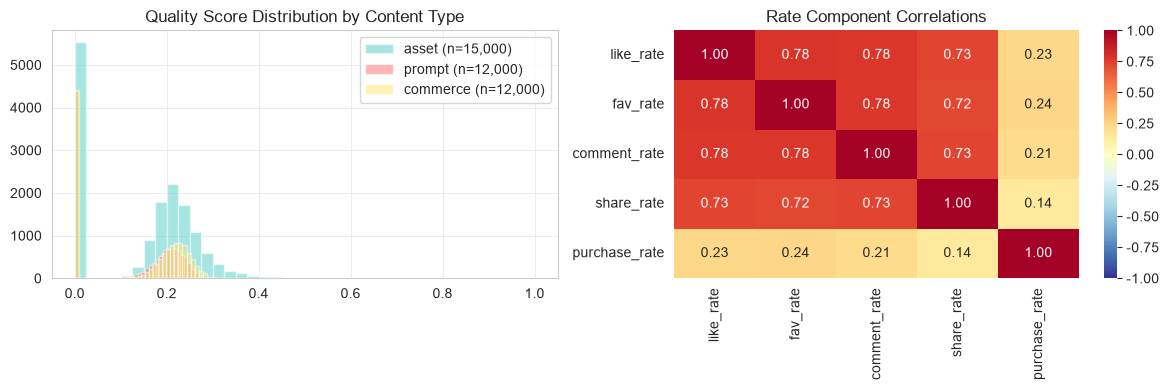

In [6]:
# F3: quality_score — content_features 中各项 rate 的加权
rate_cols = ['like_rate', 'fav_rate', 'comment_rate', 'share_rate', 'purchase_rate']
# 权重：purchase_rate 最重（真实付费信号），like/fav 居中，share/comment 较轻
rate_weights = {'like_rate': 0.25, 'fav_rate': 0.25, 'comment_rate': 0.10, 'share_rate': 0.10, 'purchase_rate': 0.30}

f3 = pd.DataFrame(index=item_full.index, columns=['quality_score'], dtype=float)

available = [c for c in rate_cols if c in item_full.columns]
print(f'Available rate columns: {available}')

f3['quality_score'] = 0.0
weight_sum = 0.0
for col in available:
    w = rate_weights.get(col, 0.2)
    vals = pd.to_numeric(item_full[col], errors='coerce').fillna(0)
    f3['quality_score'] += w * vals
    weight_sum += w

# 归一化
f3['quality_score'] /= weight_sum

# MinMax 缩放到 [0, 1]
qmin, qmax = f3['quality_score'].min(), f3['quality_score'].max()
if qmax > qmin:
    f3['quality_score'] = (f3['quality_score'] - qmin) / (qmax - qmin)

print(f'F3 quality_score: mean={f3["quality_score"].mean():.4f}, std={f3["quality_score"].std():.4f}')
print(f'Range: [{f3["quality_score"].min():.4f}, {f3["quality_score"].max():.4f}]')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ct, color in zip(ct_types, ['#4ECDC4', '#FF6B6B', '#FFE66D']):
    ct_ids = f1.loc[f1[ct] == 1].index
    axes[0].hist(f3.loc[ct_ids, 'quality_score'], bins=40, alpha=0.5,
                 label=f'{ct.split("_")[1]} (n={len(ct_ids):,})', color=color)
axes[0].set_title('Quality Score Distribution by Content Type')
axes[0].legend()

# 各 rate 分量相关性
rate_df = item_full[available].apply(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0)
corr = rate_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Rate Component Correlations')

fig.tight_layout()
plt.show()

---
## Factor 4: price_tier（1 维）
Item 价格等级，从 pricing 字段归一化

Pricing NaN rate: 0.0%
Pricing stats (raw):
count    39000.000000
mean      8537.297253
std      14649.975271
min          2.000000
25%         23.200000
50%         30.600000
75%      13715.915000
max      49993.490000
Name: pricing, dtype: float64

F4 price_tier: mean=0.4372, std=0.3278


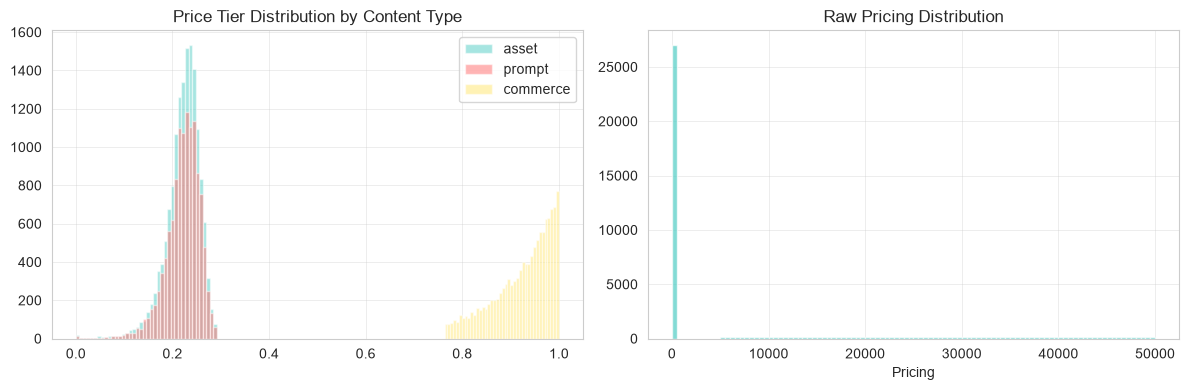

In [7]:
# F4: price_tier — pricing 归一化
f4 = pd.DataFrame(index=item_full.index, columns=['price_tier'], dtype=float)

pricing_raw = pd.to_numeric(item_full['pricing'], errors='coerce')
print(f'Pricing NaN rate: {pricing_raw.isna().mean()*100:.1f}%')
print(f'Pricing stats (raw):')
print(pricing_raw.describe())

# log1p 压缩（价格通常幂律分布）→ MinMax 归一化
pricing_log = np.log1p(pricing_raw.fillna(pricing_raw.median()))
pmin, pmax = pricing_log.min(), pricing_log.max()
f4['price_tier'] = (pricing_log - pmin) / (pmax - pmin) if pmax > pmin else 0.5

print(f'\nF4 price_tier: mean={f4["price_tier"].mean():.4f}, std={f4["price_tier"].std():.4f}')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ct, color in zip(ct_types, ['#4ECDC4', '#FF6B6B', '#FFE66D']):
    ct_ids = f1.loc[f1[ct] == 1].index
    axes[0].hist(f4.loc[ct_ids, 'price_tier'], bins=40, alpha=0.5,
                 label=f'{ct.split("_")[1]}', color=color)
axes[0].set_title('Price Tier Distribution by Content Type')
axes[0].legend()

axes[1].hist(pricing_raw.dropna(), bins=100, color='#4ECDC4', alpha=0.7)
axes[1].set_title('Raw Pricing Distribution')
axes[1].set_xlabel('Pricing')

fig.tight_layout()
plt.show()

---
## Factor 5: skill_requirements（32 维）
Item 的技能需求向量 = (title + description) → user-side TF-IDF 投影

Items with non-empty text: 39,000 / 39,000
Sample texts:
  [1] 南京CE漫展痛车展示改装合集 全流程复盘 跟着镜头看南京CE漫展的痛车展示改装合集，全车动漫贴膜、内饰主题改装、痛单车，绝绝子。
  [2] 三亚海棠湾海边草坪婚礼全纪实 月度合集 这次来到三亚海棠湾，海边草坪婚礼全纪实全记录，鲜花拱门布置、沙滩晚宴、烟花仪式让人浪漫。
  [3] 青海大环线7日自驾全攻略 连载完结 在青海大环线7日自驾全攻略，记录了青海湖日出、翡翠湖航拍、火星营地露营，超出预期。

TF-IDF matrix shape: (39000, 32)
Sparsity: 0.00%


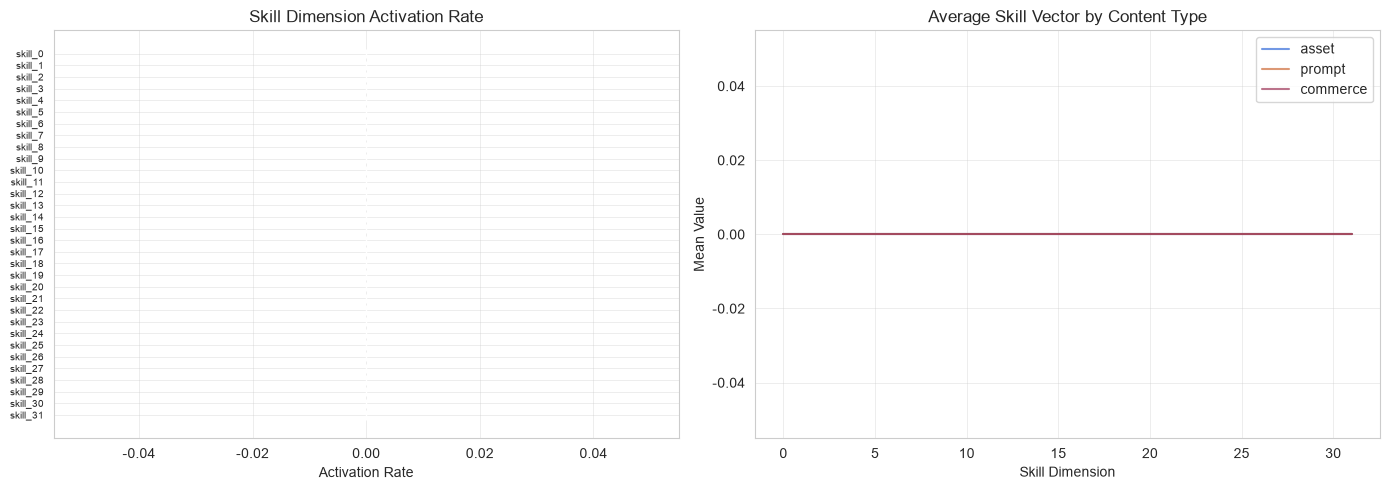

F5 skill_requirements: (39000, 32)


In [8]:
# F5: skill_requirements — item text → same TF-IDF space as user goodat
# item text = title + ' ' + description
item_texts = (item_full['title'].fillna('') + ' ' + item_full['description'].fillna(''))
print(f'Items with non-empty text: {(item_texts != "").sum():,} / {len(item_texts):,}')
print(f'Sample texts:')
for i in range(3):
    t = item_texts.iloc[i][:100]
    print(f'  [{i+1}] {t}...' if len(item_texts.iloc[i]) > 100 else f'  [{i+1}] {t}')

# 用 user-side TF-IDF transform
f5_raw = skill_tfidf.transform(item_texts)
print(f'\nTF-IDF matrix shape: {f5_raw.shape}')
print(f'Sparsity: {(f5_raw > 0).sum() / (f5_raw.shape[0] * f5_raw.shape[1]) * 100:.2f}%')

f5 = pd.DataFrame(
    f5_raw.toarray(),
    index=item_full.index,
    columns=[f'skill_{i}' for i in range(f5_raw.shape[1])]
)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 每个 skill 维度的整体激活率
activation = (f5 > 0).mean(axis=0).sort_values(ascending=False)
axes[0].barh(range(len(activation)), activation.values, color='#4ECDC4')
axes[0].set_yticks(range(len(activation)))
axes[0].set_yticklabels(activation.index, fontsize=7)
axes[0].invert_yaxis()
axes[0].set_xlabel('Activation Rate')
axes[0].set_title('Skill Dimension Activation Rate')

# 按 content type 的 skill 均值对比
skill_means = {}
for ct in ct_types:
    ct_ids = f1.loc[f1[ct] == 1].index
    skill_means[ct] = f5.loc[ct_ids].mean()
    axes[1].plot(range(32), skill_means[ct].values, label=ct.split('_')[1], alpha=0.7, linewidth=1.5)
axes[1].set_xlabel('Skill Dimension')
axes[1].set_ylabel('Mean Value')
axes[1].set_title('Average Skill Vector by Content Type')
axes[1].legend()

fig.tight_layout()
plt.show()

print(f'F5 skill_requirements: {f5.shape}')

---
## Factor 6: freshness（1 维）
Item 新鲜度 = updated_at → 相对时间归一化（越新越接近 1）

Time range: 2025-09-30 18:01:00 ~ 2026-07-01 10:32:00
F6 freshness: mean=0.5491, std=0.2266
NaN count: 0


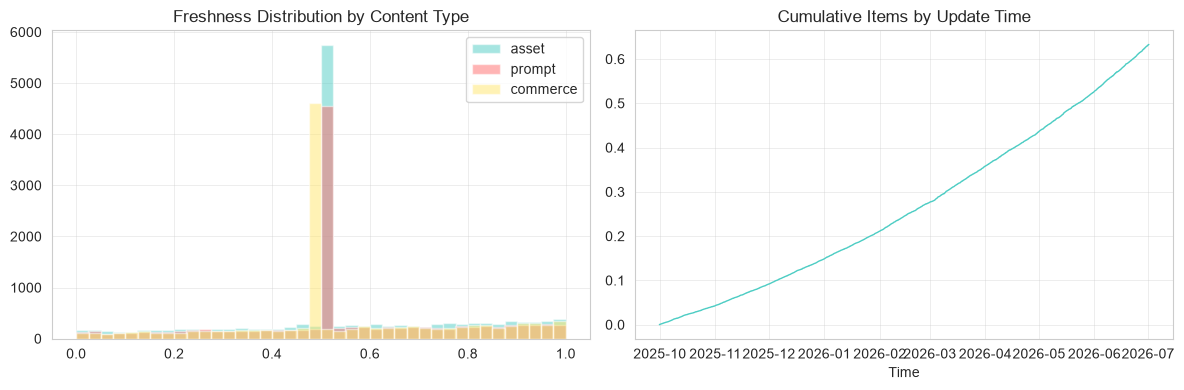

In [9]:
# F6: freshness — 从 updated_at 计算
# 越新的 item 越接近 1
f6 = pd.DataFrame(index=item_full.index, columns=['freshness'], dtype=float)

if 'updated_at' in item_full.columns:
    time_raw = pd.to_datetime(item_full['updated_at'], errors='coerce')
    tmin, tmax = time_raw.min(), time_raw.max()
    print(f'Time range: {tmin} ~ {tmax}')
    # 归一化到 [0, 1]，越新越大
    time_seconds = (time_raw - tmin).dt.total_seconds()
    max_seconds = (tmax - tmin).total_seconds()
    f6['freshness'] = time_seconds / max_seconds if max_seconds > 0 else 0.5
    n_missing = time_raw.isna().sum()
    f6.loc[time_raw.isna(), 'freshness'] = 0.5  # 缺失给中值
else:
    print('WARNING: no updated_at column, using random freshness')
    np.random.seed(42)
    f6['freshness'] = np.random.beta(2, 3, len(f6))  # 偏旧的分布

print(f'F6 freshness: mean={f6["freshness"].mean():.4f}, std={f6["freshness"].std():.4f}')
print(f'NaN count: {f6["freshness"].isna().sum()}')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ct, color in zip(ct_types, ['#4ECDC4', '#FF6B6B', '#FFE66D']):
    ct_ids = f1.loc[f1[ct] == 1].index
    axes[0].hist(f6.loc[ct_ids, 'freshness'], bins=40, alpha=0.5,
                 label=f'{ct.split("_")[1]}', color=color)
axes[0].set_title('Freshness Distribution by Content Type')
axes[0].legend()

if 'updated_at' in item_full.columns:
    axes[1].plot(time_raw.sort_values().values,
                 np.linspace(0, 1, len(time_raw)), color='#4ECDC4', linewidth=1)
    axes[1].set_title('Cumulative Items by Update Time')
    axes[1].set_xlabel('Time')

fig.tight_layout()
plt.show()

---
## Factor 7: popularity（1 维）
Item 流行度 = view_count + like_count 综合（从 published_* 表的互动计数）

Available popularity columns: ['like_rate', 'fav_rate', 'comment_rate', 'share_rate']
F7 popularity: mean=0.2132, std=0.1750
Range: [0.0000, 1.0000]


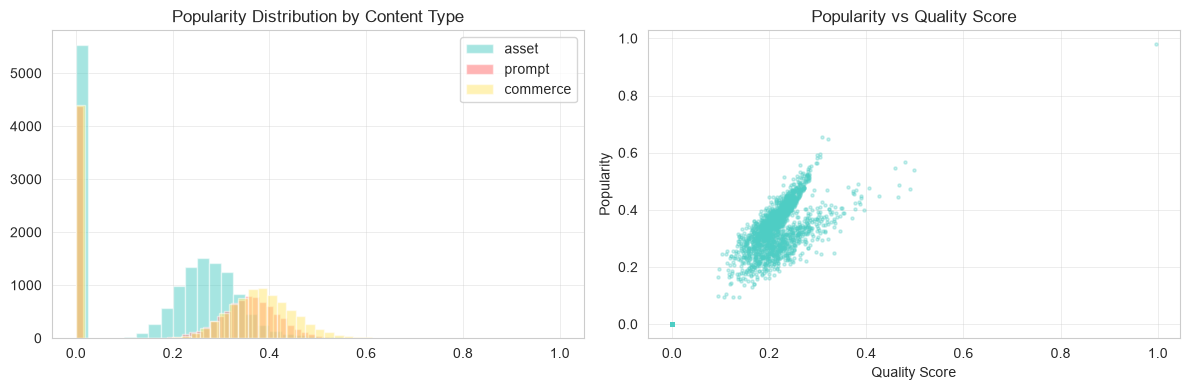

In [10]:
# F7: popularity — 从 published_* 表的互动计数综合
# Asset 表有: view_count, like_count 等
# 用 content_features 的各 rate 作为流行度的代理

f7 = pd.DataFrame(index=item_full.index, columns=['popularity'], dtype=float)

# 使用 content_features 的 like_rate + fav_rate + comment_rate + share_rate 综合
pop_cols = ['like_rate', 'fav_rate', 'comment_rate', 'share_rate']
available_pop = [c for c in pop_cols if c in item_full.columns]
print(f'Available popularity columns: {available_pop}')

f7['popularity'] = 0.0
for col in available_pop:
    vals = pd.to_numeric(item_full[col], errors='coerce').fillna(0)
    f7['popularity'] += vals
f7['popularity'] /= len(available_pop)

# MinMax 归一化
pmin, pmax = f7['popularity'].min(), f7['popularity'].max()
if pmax > pmin:
    f7['popularity'] = (f7['popularity'] - pmin) / (pmax - pmin)

print(f'F7 popularity: mean={f7["popularity"].mean():.4f}, std={f7["popularity"].std():.4f}')
print(f'Range: [{f7["popularity"].min():.4f}, {f7["popularity"].max():.4f}]')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ct, color in zip(ct_types, ['#4ECDC4', '#FF6B6B', '#FFE66D']):
    ct_ids = f1.loc[f1[ct] == 1].index
    axes[0].hist(f7.loc[ct_ids, 'popularity'], bins=40, alpha=0.5,
                 label=f'{ct.split("_")[1]}', color=color)
axes[0].set_title('Popularity Distribution by Content Type')
axes[0].legend()

# 流行度 vs 质量散点
sample = f7.sample(min(3000, len(f7)), random_state=42)
axes[1].scatter(f3.loc[sample.index, 'quality_score'],
               f7.loc[sample.index, 'popularity'],
               c='#4ECDC4', alpha=0.3, s=5)
axes[1].set_xlabel('Quality Score')
axes[1].set_ylabel('Popularity')
axes[1].set_title('Popularity vs Quality Score')

fig.tight_layout()
plt.show()

---
## 组装 & 保存
将 7 个 factor 合并为 item_latent 矩阵

In [11]:
# 组装全部 factor
# F1: 3, F2: 50, F3: 1, F4: 1, F5: 32, F6: 1, F7: 1 = 89 dims

item_latent = pd.concat([
    f1.add_prefix('ct_'),
    f2.add_prefix('theme_'),
    f3,
    f4,
    f5.add_prefix('skill_'),
    f6,
    f7,
], axis=1)

# 修复列名（去掉双重前缀）
item_latent.columns = item_latent.columns.str.replace('theme_theme_', 'theme_')
item_latent.columns = item_latent.columns.str.replace('skill_skill_', 'skill_')

print(f'Item latent matrix: {item_latent.shape}')
print(f'Columns: {list(item_latent.columns[:6])}... ({len(item_latent.columns)} total)')
print(f'NaN rate: {item_latent.isna().mean().mean()*100:.2f}%')

# 按 content type 分开看
for ct in ct_types:
    ct_ids = f1.loc[f1[ct] == 1].index
    ct_latent = item_latent.loc[ct_ids]
    print(f'\n{ct}: {len(ct_latent):,} items')
    print(f'  NaN rate: {ct_latent.isna().mean().mean()*100:.2f}%')

item_latent.head()

Item latent matrix: (39000, 89)
Columns: ['ct_published_asset', 'ct_published_prompt', 'ct_published_commerce', 'theme_svd_0', 'theme_svd_1', 'theme_svd_2']... (89 total)
NaN rate: 0.00%

published_asset: 15,000 items
  NaN rate: 0.00%

published_prompt: 12,000 items
  NaN rate: 0.00%

published_commerce: 12,000 items
  NaN rate: 0.00%


,ct_published_asset,ct_published_prompt,ct_published_commerce,theme_svd_0,theme_svd_1,theme_svd_2,theme_svd_3,theme_svd_4,theme_svd_5,theme_svd_6,...,skill_24,skill_25,skill_26,skill_27,skill_28,skill_29,skill_30,skill_31,freshness,popularity
item_id,,,,,,,,,,,,,,,,,,,,,
50e3e124-8741-4d4f-aaf8-38f913a1634e,1,0,0,0.248964,-0.109186,-0.064732,0.536173,-0.005125,0.277845,0.459261,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,0.000000
cd4cc313-ac61-4939-84c2-6e27b68aeeb1,1,0,0,0.243786,-0.180631,-0.276949,-0.083536,-0.176846,0.108476,0.127904,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,0.000000
f2e75d37-29ad-4766-9977-a491802e7edb,1,0,0,0.264582,-0.148807,0.494927,0.534518,0.181085,-0.297245,-0.258702,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.471324,0.370205
65466be4-0c3a-489b-9692-8248b761dc9a,1,0,0,0.259084,-0.103550,-0.029277,-0.210779,0.120343,0.026195,-0.029835,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.500000,0.000000
0670f212-3a89-46dd-9b5b-152e22043ace,1,0,0,0.254662,-0.106186,-0.297115,0.068292,-0.162785,-0.046460,0.118115,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.599285,0.174586


In [12]:
# 保存
import os
OUTPUT_DIR = '../data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

item_latent.to_csv(f'{OUTPUT_DIR}/item_latent.csv')
print(f'Saved item_latent ({item_latent.shape}) to {OUTPUT_DIR}/item_latent.csv')

# 同时保存 item_id → content_type 映射
item_full[['content_type']].to_csv(f'{OUTPUT_DIR}/item_content_types.csv')
print(f'Saved item content types to {OUTPUT_DIR}/item_content_types.csv')

Saved item_latent ((39000, 89)) to ../data/item_latent.csv
Saved item content types to ../data/item_content_types.csv


---
## Phase A-2 结论

1. Item latent factors 是否与 user latent 对齐到同一空间？
2. 各 factor 的分布是否合理？是否有大量零向量？
3. theme SVD 投影是否保留了 item 间的语义关系？

### 下一步：Phase A-3
构建 Match Score + 行为漏斗生成 + 验证